<center><h1> ETI195 - Ética para Ciencia de Datos y Estadística </h1><center>
<center><h2> Taller Sumativo II: Sesgos, justicia, y discriminación <h2></center>

# `Instrucciones Generales`


## `Temas formales`

**Modalidad**: Grupos de 3 o 4 personas.

**Formato de entrega:** El trabajo debe entregarse a través de Canvas, tanto en formato Jupyter ejecutable (.ipynb) como en formato PDF.

**Formalidades de las respuestas:**
- Citas: APA 7.
- Se espera buena ortografía y redacción, con respuestas en tono académico.

## `Recomendaciones`

- Asistan a los talleres formativos, revisen los ejemplos de código y consulten sus dudas con sus ayudantes.

- **Lean la rúbrica antes de hacer su tarea.**

## `Integridad académica y uso de IA`

El uso de asistentes de IA sigue los lineamientos de integridad académica del curso, con las siguientes excepciones:

- Pueden usar IA para consultar por bugs y entender mejor el código.
- Pueden usar IA para generar las representaciones visuales que estimen convenientes.

Si tienen dudas sobre el uso de IA o la citación de código externo, no duden en preguntar. Pueden usar libremente los códigos de los talleres formativos. <3

## `Contexto`

Reducir el respeto de un gobierno por los derechos humanos a un puntaje o una etiqueta binaria no es una decisión libre de impacto,  estos números son usados por organismos internacionales, ONGs y gobiernos para decidir ayuda económica, sanciones o intervención humanitaria. Un modelo entrenado sobre estos datos hereda las limitaciones de cómo se construyó el puntaje original ya sea en los criterios de codificación, por  sesgo de las fuentes usadas para calificar cada país mediante informes de prensa, ONGs, gobierno y la dificultad de capturar violaciones que ocurren en contextos con poca cobertura mediática, por lo que puede terminar prediciendo mejor la visibilidad de una violación que la violación misma.

En este taller entrenarán un modelo predictivo sobre alguna variable binaria de interés del dataset (algún derecho), por ejemplo Women's Political Rights, evaluando qué tan bien un modelo puede clasificar el respeto a ese derecho a partir de las demás variables disponibles, y discutiendo qué implicaría usar ese tipo de modelo para influir en decisiones reales sobre un país.

**Links:**
- [Datos](https://drive.google.com/file/d/1mL1oL_D1af42Uxgif-QonneldffPhGhu/view?usp=drive_link)
- [Diccionario de datos resumen](https://drive.google.com/file/d/17Fm64SksQofOmI4iNuReCsJk2o-Qghq8/view?usp=sharing)
- [Diccionario de extendido](https://drive.google.com/file/d/1cAvH2oLWW5whMiaoSEPwDmFaTqOEPqvl/view?usp=sharing)

**Integrantes:**

- Antonella Ainzúa
- Vicente de Gavardo
- Camila Matamala
- Octavia Robledo

---

## Parte 1

Lean nuevamente los materiales de contexto del dataset que pueden encontrar en la [página oficial](http://www.humanrightsdata.com/p/data-documentation.html). Deben comprender qué información captura el dataset y qué impacto podría tener entrenar modelos de clasificación en contextos de violaciones a los derechos humanos.

### **RESPONDER**

1.  Discuta los objetivos del datset CIRI con referencias a la metodología y para qué serviría entrenar un clasificador automático para predecir cumplimiento de derechos humanos, recuerden que siempre pueden apoyarse en bibliografía.

#### **R1**

* **Objetivos data set** Como describimos en el Taller I, el CIRI Human Rights Dataset contiene información cuantitativa basada en estándares sobre el respeto de los gobiernos hacia 15 derechos humanos reconocidos internacionalmente (en 202 países) y de forma anual entre 1981 y 2011.
<br>
Según el propio proyecto, esta diseñado para académicos y estudiantes pongan a prueba sus teorías sobre las causas y consecuencias de las violaciones a los derechos humanos y para que, analistas y para aquellos encargados de tomar decisicones, estimen los efectos de cambios institucionales y políticas públicas como la democratización, la ayuda económica y militar o ajustes estructurales e intervención humanitaria (Cingranelli et al, s.f).
<BR>
Su creación fue apoyada por la National Science Foundation, una agencia independiente del gobierno federal de EE.UU.

* **Metodología** CIRI no mide hechos en concreto, más bien codifica informes. Personas entrenadas leen los *Country Reports on Human Right Practices* del Departamento de Estado de EE.UU y para los derechos de integridad física, los informes de Amnistía Internacional (Cingranelli et al. s.f.).
<br>
A cada país-año le asignan un puntaje ordinal según un manual de codificación. 
<br>Por ejemplo, 0 = restricción severa, 1 = restricción moderada y 2 = respeto pleno (Cingranelli et al. 2014b).
<br>
Como vimos en el taller 1, cada atributo es una abstracción de la realidad sujeta a las decisiones y sesgos humanos que la definieron: cada numero es un juicio humano estandarizado sobre un texto, no una observación directa.

**Tener en cuenta a la hora de entrenar un modelo**
*  *Sesgo de la fuente*: Los informes del Departamento de Estado han tendido a ser más benévolos con países aliados de EE.UU. que los de Amnistía Internacional (Poe et al., 2001)
* *Efectos de información*: a medida que aumenta la cobertura de ONG y medios, se reportan más violaciones sin que necesariamente haya más (Clark & Sikkink, 2013)
* *Estándar de rendición de cuentas cambiante:* los informes se vuelven más exigentes con el tiempo, asi que un mismo puntaje no significa lo mismo en 1981 que en 2009 (Fariss, 2014).
* *Retrospección (evidencia de nuestros propios datos)*: El diccionario indica que `Freedom of Religion (New)` se creó en 2007 y que los años 1981-2006 se codificaron hacia atras (Cingranelli et al., 2014b). El 83% de las filas que usamos para entrenar son de esos años recodificados.
<br>
Además al comparar la versión antigua con la nueva para los mismos años pais-año, hay 148 casos que la versión antigua registró "sin restricciones" y la nueva como "restricciones severas" y 73 casos al revés (pueden verlo en la celda mas abajo).
<br>
La etiqueta depende de quien codifica y cuándo.

**Utilidad de un clasificador automático**
Podría servir para estimar el respeto a un derecho en país-años sin codificar (CIRI termina en 2011 y tiene vacíos por códigos especiales), además de funcionar como alerta temprana o como apoyo para priorizar el monitoreo de organismos internacionales y ONG. El riesgo es que estos puntajes ya se usan para decidir ayuda, sanciones o intervenciones.
<br>
Un modelo entrenado con ellos hereda los sesgos de la fuente y como nos dicene en el enunciado del taller, **puede terminar prediciendo mejor la *visibilidad* de una violación que la violación misma** tal como advierte el enunciado. Por eso, más que *cuánto acierta* lo importante es *para quién se equivoca*

*Fuentes: Taller Sumativo I (items 1 y 2); diccionario CIRI (Short Variable Descriptions); Formativo 1; papers citados*

## Librerias y configuraciones

In [1]:
# imports iniciales
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# 1) dividir los datos
# train_test_split: separa en entrenamiento / validación / test
# GroupShuffleSplit: igual, pero sin repetir paises entre train y test (chequeo de robustez)
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# 2) preprocesar
from sklearn.impute import SimpleImputer # rellena los NaN (usando la moda)
from sklearn.preprocessing import MinMaxScaler #normalización min-max, como en el Formativo 2

# 3) modelo
from sklearn.tree import DecisionTreeClassifier

# 4) juntamos preprocesamiento y modelo en uno solo
# asi el imputador y el scaler aprendan SOLO del entrenamiento
from sklearn.pipeline import Pipeline

# 5) elegir la profundidad del arbol con validacion cruzada
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 6) evaluando (metricas de resumen entregadas en la ayudantia)
from sklearn.metrics import accuracy_score # accuracy (lo pide el enunciado)
from sklearn.metrics import confusion_matrix # matriz de confusion (lo pide el enunciado)
from sklearn.metrics import balanced_accuracy_score # recall macro avg, no se engaña con el desbalance
from sklearn.metrics import classification_report #precision, recall, F1, macro y weighted avg

In [2]:
%pip install aequitas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# aequitas
from aequitas.group import Group

In [4]:
%pip install aif360

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# aif360
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing import EqOddsPostprocessing
from aif360.algorithms.preprocessing import Reweighing
# from aif360.metrics import BinaryLabelDatasetMetric
# from aif360.datasets import BinaryLabelDataset

import warnings
warnings.filterwarnings("ignore")

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


## Parte 2: Realice el preprocesamiento de los datos y entrene un árbol de decisión para predecir algún derecho humano de interés.

*Puede reutilizar el jupyter o trabajar con el mismo jupyter de la entrega anterior, puede entregar una carpeta con ambos jupyter y funciones compartidas*

Reporte el accuracy y la matriz de confusión sobre los datos de testeo.

### Resumen de lo realizado en la entrega anterior:

In [6]:
# LECTURA DE DATOS
df = pd.read_csv('Data/ciri_data.csv')

# CORRECCIÓN TIPO DE DATOS
df["UN Country ID"] = df["UN Country ID"].astype("Int64")

# esto lo debi agregar para este taller
# antes de limpiar, guardamos por paiss la proporción de años con algun
# codigo especial en las columnas de derechos.
# Lo usamos como atributo sensible en la Parte 3.
fila_con_codigo = df[df.columns[6:]].isin([-999, -77, -66]).any(axis=1)
df['prop_codigos_esp'] = fila_con_codigo.groupby(df['Country']).transform('mean')

# Eliminación datos menores a 0
df_clean = df.copy()
columnas_derechos = df_clean.columns[6:-1] #con el -1 excluimos la columna nueva prop_codigos_esp

codigos_especiales = [-999, -77, -66]

for columna in columnas_derechos:
  df_clean[columna] = df_clean[columna].replace(codigos_especiales, np.nan)

# Estandarizamos todos los tipos de nulos a 'np.nan' por conversión de tipo
for columna in columnas_derechos:
    df_clean[columna] = pd.to_numeric(df_clean[columna], errors="coerce").astype(float)

# SELECCIÓN DE COLUMNAS (DERECHOS) DE INTERÉS
df_test = df_clean.copy()
# Convertir a tipo categoría Region y Subregion
df_test['UN Subregion'] = df_test['UN Subregion'].astype("category")
df_test['UN Region'] = df_test['UN Region'].astype("category")

# Filtramos por año >= 2000 en que Freedom of Religion es == 2
df_filtrado = df_test[(df_test["Year"] >= 2000) & (df_test["Freedom of Religion (New)"] == 2)]
# Se hace un conteo de los casos y se agrupna por Year y Sub region
conteo_por_año = (df_filtrado.groupby(["Year", "UN Subregion"], observed=True).size().reset_index(name="Cantidad_Casos"))

# print("\t SUBREGIONES CON FREEDOM OF RELIGION (NEW) == 2 POR AÑO (DESDE EL 2000)\n")
# print(conteo_por_año.to_string(index=False))# No muestra el indice

In [7]:
# DISTRIBUCIÓN DE LOS ATRIBUTOS ELEGIDOS DENTRO DE LA SUBPOBLACIÓN
# Relación entre Freedom of Religion (New) y Women's Social Rights
# Se descartan NaN en ambas columnas para esta comparación puntual
df_relacion = df_clean[["Freedom of Religion (New)", "Women’s Social Rights"]].dropna()
df_relacion = df_relacion.astype(int)

# Tabla de conteo (cuántos país-año caen en cada combinación)
tabla_conteo = pd.crosstab(
    df_relacion["Freedom of Religion (New)"],
    df_relacion["Women’s Social Rights"],
)
print("\t CONTEO: FREEDOM OF RELIGION (NEW) x WOMEN'S SOCIAL RIGHTS\n")
print(tabla_conteo.to_string())

# Tabla porcentual: dentro de cada nivel de libertad religiosa,
# cómo se distribuyen los derechos sociales de las mujeres
tabla_pct = pd.crosstab(
    df_relacion["Freedom of Religion (New)"],
    df_relacion["Women’s Social Rights"],
    normalize="index",
) * 100
print("\n\t % POR FILA (dentro de cada nivel de Freedom of Religion)\n")
print(tabla_pct.round(1).to_string())

	 CONTEO: FREEDOM OF RELIGION (NEW) x WOMEN'S SOCIAL RIGHTS

Women’s Social Rights        0    1    2    3
Freedom of Religion (New)                    
0                          246  431  127    6
1                          200  495  177   50
2                          184  918  521  293

	 % POR FILA (dentro de cada nivel de Freedom of Religion)

Women’s Social Rights         0     1     2     3
Freedom of Religion (New)                        
0                          30.4  53.2  15.7   0.7
1                          21.7  53.7  19.2   5.4
2                           9.6  47.9  27.2  15.3


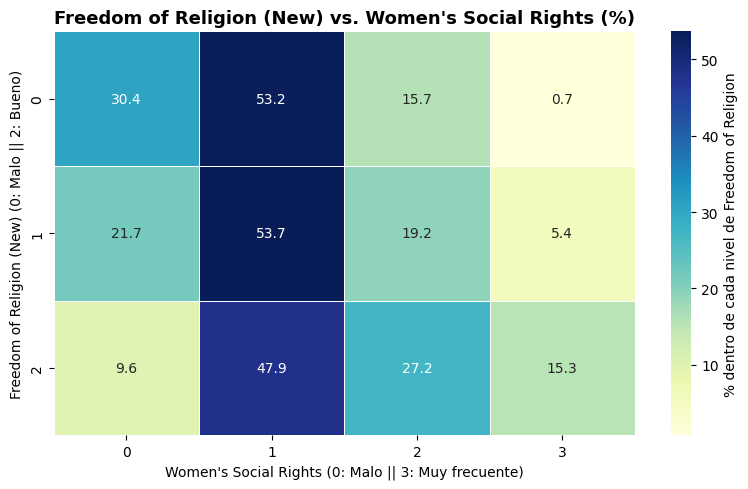

In [8]:
# Heatmap para visualizar la relación
plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "% dentro de cada nivel de Freedom of Religion"},
    linewidths=0.5,
    linecolor="white",
)

plt.title("Freedom of Religion (New) vs. Women's Social Rights (%)", fontsize=13, fontweight="bold")
plt.xlabel("Women's Social Rights (0: Malo || 3: Muy frecuente)")
plt.ylabel("Freedom of Religion (New) (0: Malo || 2: Bueno)")
plt.tight_layout()
plt.show()

### Indicaciones

**1 Elección del tipo de clasificador**

Dependiendo del atributo que escoja, podría tener que entrenar un clasificador binario o un clasificador multiclase:

- Un clasificador binario se utiliza cuando la variable objetivo es binaria, como en el caso de Freedom of Religion, que tiene como opciones 0 o 1.
- Un clasificador multiclase se utiliza cuando la variable objetivo tiene más de dos categorías, como en el caso de Worker's Rights, que tiene las opciones 0, 1 y 2.
- Para casos de mayor dimensión, recomiendo evaluar la manera de binarizar o disminuir la dimensión; recuerden que estas decisiones siempre deben estar justificadas.

**2 Manejo de códigos especiales**

La `**variable objetivo**` debe restringirse a los valores que efectivamente miden el derecho humano en cuestión, excluyendo los siguientes 3 casos especiales que contempla el libro de código [-999, -77, -66]. Si el caso cae en alguno de estos 3 códigos, se debe tomar una decisión de limpieza sobre esos datos mediante la técnica de manejo de valores faltantes que estimen conveniente. Esta decisión no es trivial y puede afectar mucho el modelo, deben reflexionar al respecto.

**3 Otras indicaciones del preprocesamiento**

- El preprocesamiento debe incluir al menos: manejo de valores faltantes, codificación de variables categóricas, normalización de variables numéricas y tratamiento de valores extremos.

- Utilice random_state o semillas donde corresponda para garantizar la reproducibilidad de los resultados.

- La variable objetivo podría estaár desbalanceada. Investigue el argumento class_weight='balanced' de sklearn para manejar este problema y aplíquelo si lo considera pertinente.

### **RESPONDER**

2.1 Explique y justifique los pasos del preprocesamiento.

2.2 ¿Podemos concluir en este punto, que el modelo tiene el mismo rendimiento para todos los grupos sensibles del dataset? Entienda como grupos sensibles aquellos que pueden verse afectados por sesgos sistemáticos de un sistema de clasificación, como discutimos en la introducción; podrían ser grupos de países con mayor pobreza o menor cobertura mediática.

### Respuestas:

#### **Eleccion de la variable objetivo** 

✿ -------------------- ✿ ----------------------- ✿
<br>
*Recordatorio definiciones*

**Variable objetivo**: la columna que el modelo quiere predecir.

**Etiqueta (label)**: el valor de esa variable en cada fila, es decir, la "respuesta" de cada caso. 
<br>
✿ -------------------- ✿ ----------------------- ✿

In [9]:
#tanteando el terreno
candidatas = [
    'Freedom of Religion (New)',
    'Women’s Economic Rights',
    'Women’s Political Rights',
    'Women’s Social Rights',
]

faltantes = pd.DataFrame({
    'n_faltantes': df_clean[candidatas].isna().sum(),
    'pct_faltantes': (df_clean[candidatas].isna().mean() * 100).round(1),
})
print(f"Total de filas (país-año): {len(df_clean)}\n")
print(faltantes.sort_values('pct_faltantes').to_string())

Total de filas (país-año): 6262

                           n_faltantes  pct_faltantes
Freedom of Religion (New)          720           11.5
Women’s Political Rights          1335           21.3
Women’s Economic Rights           1385           22.1
Women’s Social Rights             2609           41.7


#### **¿Por qué la versión New y no la Old?**
El enunciado menciona Freedom of Religion como variable binaria (0 o 1), lo que corresponde a la version Old que ya viene binarizada.
<br>
Por eso consideramos usarla.
<br>
Además, nos surgieron dudas el binarizar la version New, ya que sería pasar todo a "blanco y negro" y perder los matices de su escala (0 = restricciones severas y generalizadas, 1 = moderadas, 2 = prácticamente ausentes; Cingranelli et al., 2014b): un país con persecución religiosa sistemática y uno con restricciones menores pasarían a ser "lo mismo". Tal como advierte el contexto del enunciado, "reducir el respeto de un gobierno por los derechos humanos a un puntaje o una etiqueta binaria no es una decisión libre de impacto".

Sin embargo, binarizar es necesario: las herramientas de fairness que usamos en las Partes 3 a 5 (Aequitas y aif360) requieren una etiqueta binaria. Y la version Old no evita esta pérdida de matices, porque su valor 0 ("el gobierno restringió algunas prácticas") ya agrupa desde restricciones menores hasta persecución sistemática. Usarla no elimina la simplificación, solo impide que nosotros decidamos y justifiquemos dónde se hace el corte.
<br>
Para decidir, comparamos ambas versiones con los datos:


In [10]:
# df_clean ya tiene los códigos especiales (-999, -77, -66) convertidos a NaN.
versiones = ['Freedom of Religion (Old)', 'Freedom of Religion (New)']

resumen = pd.DataFrame({
    'valores': [sorted(df_clean[c].dropna().astype(int).unique()) for c in versiones],
    'primer_año': [df_clean.loc[df_clean[c].notna(), 'Year'].min() for c in versiones],
    'último_año': [df_clean.loc[df_clean[c].notna(), 'Year'].max() for c in versiones],
    'filas_válidas': [df_clean[c].notna().sum() for c in versiones],
    'pct_faltantes': [round(df_clean[c].isna().mean() * 100, 1) for c in versiones],
}, index=versiones)
print(f"Total de filas (país-año): {len(df_clean)}\n")
print(resumen.to_string())

# Cobertura por periodo (% de filas con dato válido)
periodos = pd.cut(df_clean['Year'], bins=[1980, 1999, 2006, 2011],
                  labels=['1981-1999', '2000-2006', '2007-2011'])
print("\n% de filas con dato válido por periodo:")
print((df_clean[versiones].notna().groupby(periodos, observed=True).mean() * 100).round(1).to_string())

# coinciden ambas versiones? Old = 1 ("sin restricciones") vs New = 2 ("prácticamente ausentes")
ambas = df_clean[versiones].notna().all(axis=1)
coinciden = (df_clean['Freedom of Religion (Old)'] == 1) == (df_clean['Freedom of Religion (New)'] == 2)
print(f"\nCoincidencia entre versiones: {coinciden[ambas].mean() * 100:.1f}% de {ambas.sum()} país-años con ambas")

Total de filas (país-año): 6262

                             valores  primer_año  último_año  filas_válidas  pct_faltantes
Freedom of Religion (Old)     [0, 1]        1981        2006           3982           36.4
Freedom of Religion (New)  [0, 1, 2]        1981        2011           5542           11.5

% de filas con dato válido por periodo:
           Freedom of Religion (Old)  Freedom of Religion (New)
Year                                                           
1981-1999                       70.8                       84.7
2000-2006                       89.4                       94.0
2007-2011                        0.0                       95.4

Coincidencia entre versiones: 81.2% de 3977 país-años con ambas


Los datos respaldan el uso de la versión New:
* **Cobertura temporal:** la versión Old solo cubre 1981–2006 y fue retirada por CIRI a partir de 2007 (Cingranelli et al., 2014b). La versión `New` aunque se creó en 2007, fue recodificada hacia atrás y cubre todo el periodo 1981–2011.
* **Cantidad de datos:** la versión Old tiene 3.982 filas validas (36,4% de faltantes) contra 5.542 de la versión New (11,5% de faltantes). Incluso en los años en que ambas existen, la New tiene mejor cobertura (84,7% contra 70,8% entre 1981 y 1999).
* **Coherencia entre versiones:** en los 3.977 país-años donde ambas tienen dato, el valor 1 de la Old ("sin restricciones") coincide con el valor 2 de la New ("prácticamente ausentes") en un 81,2% de los casos. Esto indica que cortar la versión New en el valor 2 sigue una lógica similar a la de la Old, pero con más datos y con un corte que podemos justificar.

#### **elección final variable objetivo** `Freedom of Religion (New)`
Elegimos este derecho por tres razones:
1. **Continuidad con el taller I**: en los items 5.1 y 5.2 ya analizamos su distribución y su relación con `UN Subregion` y `Women's Social Rights`
2. **Calidad de los datos**: tiene solo un 11.5% de faltantes contra los 21% y 42% de los derechos de la mujer y en el taller I ninguna de sus categorías apareció con frecuencia muy baja.
3. **Relevancia ética**: la libertad religiosa es un derecho individual cuyo respeto varía mucho según el contexto geopolítico, lo que la hace sensible a sesgos regionales.

Como ya mencionamos anteriormente, variable originalmente tiene 3 niveles (0, 1 y 2).
<br>
Como nos indican en el enunciado, en casos de mayor dimension (a 2) debemos evaluar como binarizar.
<br>
La binarizamos para entrenar un clasificador binario, que es lo que requiere Aequitas y aif360.

Por lo tanto, binarizamos la versión New en 1 = respeto pleno (valor 2) y 0 = restricción severa o moderada (valores 0 y 1), reconociendo que esta decisión agrupa en una misma categoría situaciones de gravedad distinta.

✿*Recordando el formativo 1*: definir qué se predice es también decidir qué importa

✿ -------------------- ✿ ----------------------- ✿
<br>
*Paréntesis intersante de semillas aprendidas en intro a progra con Cristian Ruz*
<br>
Una semilla (seed o random_state) es el valor inicial de un generador de números **pseudoaleatorios**.

Los computadores no generan azar "verdadero". Usan un algoritmo determinista que partiendo de un número inicial, produce una secuencia de números que parece aleatoria. Por eso se llaman pseudoaleatorios. Ese número inicial es la semilla, dando pie a las siguientes conclusiones:

* Misma semilla -> misma secuencia. Por eso los resultados son **reproducibles**.
* Semilla distinta -> secuencia distinta. Por eso cambian que filas caen en el test y los números varian un poco.


✿ -------------------- ✿ ----------------------- ✿

In [11]:
# definiendo semilla unica para todo el notebook
SEED = 42

# eliminacion de duplicados 
# en un panel pais-año, además de filas identicas revisamos que no se repita
# el mismo pais-año
print("Filas completamente duplicadas:", df_clean.duplicated().sum())
print("Combinaciones pais-año repetidas:", df_clean.duplicated(subset=['Country', 'Year']).sum())


Filas completamente duplicadas: 0
Combinaciones pais-año repetidas: 0


In [12]:
OBJETIVO = 'Freedom of Religion (New)'

# como viene la variable objetivo en los datos crudos? (incluyendo codigos especiales y vacios)
print("Variable objetivo en datos crudos:")
print(df[OBJETIVO].value_counts(dropna=False).sort_index())

Variable objetivo en datos crudos:
Freedom of Religion (New)
-999.0       3
-77.0       67
-66.0       28
 0.0      1187
 1.0      1306
 2.0      3049
 NaN       622
Name: count, dtype: int64


#### **Confiabilidad etiqueta**
Según el diccionario de CIRI, `Freedom of Religion (New)` "is new for 2007 and will be back-coded for years 1981-2006" (Cingranelli et al., 2014b).
<br>
Para esos años también existe la versión antigua del mismo derecho (`Old`, escala 0/1) asi que podemos comparar dos codificaciones del mismo país-año.


In [13]:
anios_recodificados = df_clean[OBJETIVO].notna() & (df_clean['Year'] < 2007)
print(f"Filas con objetivo valido que son de años recodificados (1981-2006): "
      f"{anios_recodificados.sum()} de {df_clean[OBJETIVO].notna().sum()}")

print("\nOld (0 = restringio algunas practicas, 1 = sin restricciones) vs New (0, 1, 2):")
pd.crosstab(df_clean['Freedom of Religion (Old)'], df_clean[OBJETIVO])

Filas con objetivo valido que son de años recodificados (1981-2006): 4578 de 5542

Old (0 = restringio algunas practicas, 1 = sin restricciones) vs New (0, 1, 2):


Freedom of Religion (New),0.0,1.0,2.0
Freedom of Religion (Old),,,
0.0,747,501,73
1.0,148,525,1983


#### **Decisiones sobre la variable objetivo**
* **Datos faltantes y códigos especiales**: eliminamos esas filas que es una de las opciones del Formativo 2 para nulos (`dropna`). Imputar la variable objetico significaría *inventar* la etiqueta que el modelo debe aprender.

* **Binarización**: 1 = respeto pleno (valor 2, restricciones "prácticamente ausentes" según el diccionario) y `0` = restricción severa o moderada (valores 0 y 1). El corte responde a una pregunta con sentido sustantivo ¿el Estado respeta plenamente la libertad religiosa? además deja clases de tamaño similar.

In [14]:
# decision 1: filas sin valor real en el objetivo se eliminan (no se imputan)
# no imputamos para no inventarle al modelo lo que debe aprender
df_modelo = df_clean[df_clean[OBJETIVO].notna()].copy()
print(f"Filas eliminadas por objetivo faltante o código especial: {len(df_clean) - len(df_modelo)}")

# regiones que pierden mas filas con esta decision
perdidas = (df_clean[OBJETIVO].isna()
            .groupby(df_clean['UN Region']).mean()
            .sort_values(ascending=False) * 100)
print("\n% de filas eliminadas por región:")
print(perdidas.round(1).to_string())

# que tipo de código especial tenia el objetivo en cada region? (solo -77 y -66 indican crisis)
codigos_objetivo = df[df[OBJETIVO].isin(codigos_especiales)]
print("\nCódigos especiales del objetivo por región:")
print(pd.crosstab(codigos_objetivo['UN Region'], codigos_objetivo[OBJETIVO].astype(int)).to_string())

# decision 2: binarizae
# 1 = respeto pleno (valor 2), 0 = restriccion severa o parcial (valores 0 y 1)
df_modelo['y'] = (df_modelo[OBJETIVO] == 2).astype(int)

print("\nDistribución de la variable binaria:")
print(df_modelo['y'].value_counts())
print((df_modelo['y'].value_counts(normalize=True) * 100).round(1))

Filas eliminadas por objetivo faltante o código especial: 720

% de filas eliminadas por región:
UN Region
Europe                             23.5
Asia                               13.4
Oceania                            12.7
Africa                              5.7
Latin America and the Caribbean     0.5
North America                       0.0

Códigos especiales del objetivo por región:
Freedom of Religion (New)        -999  -77   -66 
UN Region                                        
Africa                              1    51     0
Asia                                0    13    22
Europe                              0     3     6
Latin America and the Caribbean     1     0     0
Oceania                             1     0     0

Distribución de la variable binaria:
y
1    3049
0    2493
Name: count, dtype: int64
y
1    55.0
0    45.0
Name: proportion, dtype: float64


**Selección de predictores**
<br> (Formativo 2: separar variables predictoras **X** y variable a predecir **y**).
<br>
Usamos los demás derechos y el año, dejando fuera tres tipos de columnas:
* **Identificadores** para que el modelo no memorice países
* **Atributos sensibles** (región y subregión) que reservamos para la auditoría
* **Variables con fuga de información (data leakage)** según el diccionario de CIRI, el `Empowerment Right Index (New)` es "an additive index constructed from [...] Freedom Religion" (Cingranelli et al. 2014b). Si lo usaramos, el modelo vería parte de la respuesta y el accuracy saldría artificialmente alto.

In [15]:
# seleccionando predictores
predictores = [
    'Year', 'Disappearance', 'Extrajudicial Killing', 'Political Imprisonment', 'Torture',
    'Freedom of Assembly and Association', 'Freedom of Foreign Movement',
    'Freedom of Domestic Movement', 'Freedom of Speech', 'Electoral Self-Determination',
    'Employment Rights', 'Women’s Economic Rights', 'Women’s Political Rights',
    'Women’s Social Rights', 'Independence of Judiciary',
]

# Columnas que NO entran al modelo y por qué:
# - CIRI Country ID / Country / UN Country ID -> identificadores: el modelo memorizaria países
# - UN Region / UN Subregion -> atributos sensibles: se reservan para la auditoría (Parte 3)
# - Empowerment Rights Index (New) -> fuga de informacion: su suma incluye Freedom of Religion (New)
# - Empowerment Rights Index (Old) -> fuga de informacion: su suma incluye Freedom of Religion (Old)
# - Freedom of Religion (Old) -> fuga de informacion: mide el mismo derecho con otra escala
# - Physical Integrity Rights Index -> redundante: es la suma de sus 4 componentes, que si entran
# - Freedom of Movement (Old) -> redundante y retirada: reemplazada por Foreign/Domestic Movement

X = df_modelo[predictores]
y = df_modelo['y']

print("% de valores faltantes por predictor (en las filas del modelo):")
print((X.isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

% de valores faltantes por predictor (en las filas del modelo):
Women’s Social Rights                  34.2
Women’s Economic Rights                12.1
Women’s Political Rights               11.2
Extrajudicial Killing                  11.1
Disappearance                          11.1
Torture                                11.0
Political Imprisonment                 11.0
Freedom of Assembly and Association    10.9
Employment Rights                      10.8
Electoral Self-Determination           10.8
Freedom of Speech                      10.8
Independence of Judiciary               0.8
Freedom of Foreign Movement             0.1
Freedom of Domestic Movement            0.1
Year                                    0.0


In [16]:
# Tratamiento de valores extremos
# El Formativo 2 usa el criterio IQR (Q1 - 1.5*IQR, Q3 + 1.5*IQR), pensado para variables continuas
# como la edad.
# En escalas ordinales de 0 a 2 o de 0 a 3 ese criterio no tiene sentido: un 0 no es "extremo",
# es un puntaje valido (y justo el mas grave).
# En CIRI los unicos valores imposibles eran los códigos especiales (ya eliminados),
# asi que verificamos que todo quede dentro del rango que indica el diccionario
# de CIRI (Short Variable Descriptions).
rangos_diccionario = {
    'Disappearance': (0, 2), 'Extrajudicial Killing': (0, 2), 'Political Imprisonment': (0, 2),
    'Torture': (0, 2), 'Freedom of Assembly and Association': (0, 2),
    'Freedom of Foreign Movement': (0, 2), 'Freedom of Domestic Movement': (0, 2),
    'Freedom of Speech': (0, 2), 'Electoral Self-Determination': (0, 2), 'Employment Rights': (0, 2),
    'Women’s Economic Rights': (0, 3), 'Women’s Political Rights': (0, 3),
    'Women’s Social Rights': (0, 3), 'Independence of Judiciary': (0, 2), 'Year': (1981, 2011),
}
fuera_de_rango = 0
for col, (minimo, maximo) in rangos_diccionario.items():
    n = ((X[col] < minimo) | (X[col] > maximo)).sum()
    fuera_de_rango += n
    if n > 0:
        print(col, "tiene", n, "valores fuera de rango")
print("Total de valores fuera del rango del diccionario:", fuera_de_rango)

Total de valores fuera del rango del diccionario: 0


In [17]:
# Division 60% entrenamiento/20% validacion/ 20% test, estratificada por la clase
# La validacion se reserva para ajustar EqOddsPostprocessing en la Parte 4
# (asi el post-procesamiento no "mira" el test).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

print("Entrenamiento:", X_train.shape, "| Validación:", X_val.shape, "| Test:", X_test.shape)
print("Proporción de clase 1 en cada parte:",
      round(y_train.mean(), 3), round(y_val.mean(), 3), round(y_test.mean(), 3))

Entrenamiento: (3325, 15) | Validación: (1108, 15) | Test: (1109, 15)
Proporción de clase 1 en cada parte: 0.55 0.551 0.55


In [18]:
# debo admitir que ocupe ia en esta parte ya qu eno etendia bien el tema del arbol
# de decision y como normalizar para pasarlo a arbol.
# mputación -> normalización -> árbol.
# Todo se ajusta SOLO con entrenamiento, para que la moda o la media del test no se filtren.
def crear_pipeline(class_weight):
    return Pipeline([
        # moda: mantiene valores válidos de la escala ordinal (la media daría 1.37, que no existe)
        # add_indicator: agrega una columna 0/1 que marca dónde faltaba el dato
        ('imputar', SimpleImputer(strategy='most_frequent', add_indicator=True)),
        # normalización min-max (Formativo 2): lleva cada variable al rango 0-1
        ('normalizar', MinMaxScaler()),
        ('arbol', DecisionTreeClassifier(class_weight=class_weight, random_state=SEED)),
    ])

# Buscamos la profundidad del árbol con validación cruzada dentro del entrenamiento.
grilla = {
    'arbol__max_depth': [3, 4, 5, 6, 8, 10],
    'arbol__min_samples_leaf': [1, 5, 10, 20],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = []
modelos = {}
for cw in [None, 'balanced']:
    busqueda = GridSearchCV(crear_pipeline(cw), grilla, cv=cv, scoring='balanced_accuracy')
    busqueda.fit(X_train, y_train)
    modelos[str(cw)] = busqueda.best_estimator_
    resultados.append({
        'class_weight': str(cw),
        'max_depth': busqueda.best_params_['arbol__max_depth'],
        'min_samples_leaf': busqueda.best_params_['arbol__min_samples_leaf'],
        'balanced_accuracy_CV': round(busqueda.best_score_, 3),
        'accuracy_validacion': round(accuracy_score(y_val, busqueda.predict(X_val)), 3),
    })
pd.DataFrame(resultados)

,class_weight,max_depth,min_samples_leaf,balanced_accuracy_CV,accuracy_validacion
0,None,4,1,0.771,0.750
1,balanced,4,1,0.771,0.737


In [19]:
# modelo final: sin class_weight (justificacion en 2.1)
modelo = modelos['None']
pred_test = modelo.predict(X_test)

print(f"Accuracy en test: {accuracy_score(y_test, pred_test):.3f}")
print(f"Balanced accuracy en test: {balanced_accuracy_score(y_test, pred_test):.3f}\n")
print(classification_report(y_test, pred_test, 
                            target_names=['0: restringido', '1: respeto pleno']))

Accuracy en test: 0.755
Balanced accuracy en test: 0.752

                  precision    recall  f1-score   support

  0: restringido       0.73      0.73      0.73       499
1: respeto pleno       0.78      0.78      0.78       610

        accuracy                           0.75      1109
       macro avg       0.75      0.75      0.75      1109
    weighted avg       0.75      0.75      0.75      1109



In [20]:
# Comprobacion: un arbol no depende de la escala de las variables
# Entrenamos el mismo arbol SIN el paso de normalizacion y comparamos las predicciones
arbol_sin_normalizar = Pipeline([
    ('imputar', SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ('arbol', DecisionTreeClassifier(max_depth=modelo.get_params()['arbol__max_depth'],
                                     min_samples_leaf=modelo.get_params()['arbol__min_samples_leaf'],
                                     random_state=SEED)),
])
arbol_sin_normalizar.fit(X_train, y_train)
iguales = (arbol_sin_normalizar.predict(X_test) == pred_test).mean() * 100
print(f"Predicciones iguales con y sin normalizar: {iguales:.1f}%")

Predicciones iguales con y sin normalizar: 100.0%


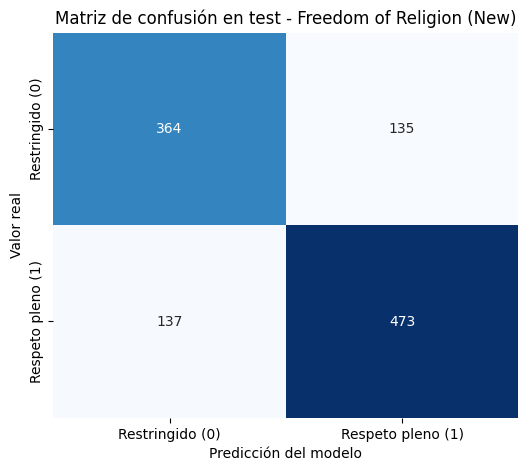

In [21]:
# Matriz de confusion
matriz = confusion_matrix(y_test, pred_test)
etiquetas = ['Restringido (0)', 'Respeto pleno (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión en test - Freedom of Religion (New)')
plt.show()

In [22]:
# ¿cmo se componen los datos de test por region? 
# (sin mirar todavía el desempeño del modelo)
composicion = df_modelo.loc[X_test.index].groupby('UN Region').agg(
    n_casos=('y', 'size'),
    pct_respeto_pleno=('y', 'mean'),
)
composicion['pct_del_test'] = composicion['n_casos'] / composicion['n_casos'].sum() * 100
composicion['pct_respeto_pleno'] *= 100
print(composicion.round(1).sort_values('n_casos', ascending=False).to_string())

                                 n_casos  pct_respeto_pleno  pct_del_test
UN Region                                                                
Africa                               306               56.5          27.6
Asia                                 264               15.9          23.8
Europe                               223               60.5          20.1
Latin America and the Caribbean      215               76.3          19.4
Oceania                               87               94.3           7.8
North America                         14              100.0           1.3


In [23]:
# extra: la base es un panel pais-año
# con una division aleatoria, un mismo pais aparece en entrenamiento y en test
# (años distintos) y el modelo puede apoyarse en ese "parecido"
# probamos que pasa si el test tiene solo paises que el modelo nunca vio
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_tr, idx_te = next(gss.split(X, y, groups=df_modelo['Country']))

modelo_paises = crear_pipeline(None)
modelo_paises.set_params(**{k: v for k, v in modelo.get_params().items()
                            if k in ['arbol__max_depth', 'arbol__min_samples_leaf']})
modelo_paises.fit(X.iloc[idx_tr], y.iloc[idx_tr])
acc_paises = accuracy_score(y.iloc[idx_te], modelo_paises.predict(X.iloc[idx_te]))

print(f"Accuracy con división aleatoria de filas: {accuracy_score(y_test, pred_test):.3f}")
print(f"Accuracy con países nuevos (no vistos): {acc_paises:.3f}")

Accuracy con división aleatoria de filas: 0.755
Accuracy con países nuevos (no vistos): 0.739


### Respuesta 2.1

Seguimos los pasos generales de limpieza del Formativo 2 (valores faltantes, duplicados, outliers, inconsistencias y tipos de datos) y los adaptamos a CIRI.

**1. Códigos especiales (-999, -77, -66) -> `NaN`**
Reutilizamos la detección generica del Taller I.
<br>
El diccionario de CIRI pide excluir estos valores porque no son puntajes: -999 es dato faltante, -77 interregno y -66 interrupción u ocupación extranjera (Cingranelli et al., 2014b). Antes de eliminarlos guardamos por país la proporción de años con alguno de estos códigos, que usaremos como atributo sensible en la Parte 3.

**2. Duplicados.** Revisamos filas idénticas y combinaciones pais-año repetidas: **0 en ambos casos**, asi que no hubo que eliminar nada.

**3. Faltantes del objetivo: se eliminan (720 filas, 11,5%).** Son 622 filas vacías y 98 con códigos especiales.
<br>
Eliminamos esas filas (equivalente a `dropna`, una de las opciones del Formativo 2) y **no** imputamos la etiqueta porque eso significaria inventar la respuesta que el modelo debe aprender.
<br>
Esta decisión no es neutra, porque la pérdida no se distribuye de forma pareja entre regiones:
- Europa pierde el 23,5% de sus filas, pero casi todas corresponden a años en que el país no tenía ningún derecho codificado (países que aún no existían, como Kosovo, Serbia o Montenegro, o que dejaron de existir, como la Unión Soviética o Checoslovaquia). Es una ausencia estructural del panel.
- En cambio, los códigos **-77 (interregno)** se concentran en África (51 casos) y los **-66 (ocupación)** en Asia (22 casos). Al eliminarlos, el modelo nunca ve contextos de colapso estatal o guerra, que son los de mayor vulnerabilidad. Es un **sesgo de representación**.

**4. Binarización de la variable objetivo.** Codificamos 1 = respeto pleno (valor 2, restricciones "prácticamente ausentes") y 0 = restricción severa o moderada (valores 0 y 1). Resultado: 55,0% de clase 1 y 45,0% de clase 0.
- *Por qué binarizar:* las herramientas de fairness de las Partes 3 a 5 (Aequitas y aif360) requieren una etiqueta binaria, y el enunciado recomienda binarizar las variables objetivo de mayor dimensión.
- *Por qué el corte en 2:* responde una pregunta con sentido sustantivo (*¿el Estado respeta plenamente la libertad religiosa?*), deja clases equilibradas y sigue la lógica de la versión Old: ambas versiones coinciden en un 81,2% de los país-años.
- *Por qué la versión New y no la Old:* ver la sección "¿Por qué la versión New y no la Old?".
- *Qué se pierde:* la clase 0 agrupa 1.187 país-años con restricciones severas y 1.306 con restricciones moderadas. Para el modelo, un país con persecución religiosa sistemática y uno con restricciones menores pasan a ser "lo mismo". Como advierte el contexto del enunciado, reducir el respeto de un gobierno a una etiqueta binaria "no es una decisión libre de impacto". (cosas que ya dijimos mientras analizabamos todo pero asi se sintetiza la respuesta en esta sección)

**5. Selección de predictores.** Excluimos identificadores (para que el modelo no memorice paises), atributos sensibles (reservados para la auditoría) y variables con fuga de informacion (ver comentarios en la celda de selección de predictores).
<br>
Según el diccionario, el `Empowerment Rights Index (New)` es un índice aditivo que incluye a `Freedom of Religion (New)` (Cingranelli et al., 2014b): usarlo sería entregarle al modelo parte de la respuesta. También sacamos el `Physical Integrity Rights Index` porque es la suma exacta de sus cuatro componentes, que si incluimos.

**6. Faltantes de los predictores: imputación por moda + indicador.**
- El Formativo 2 propone rellenar con *"0, media, mediana, moda, etc."*.
<br>
Elegimos la **moda** porque las escalas son ordinales: la media produciria valores que no existen en la escala CIRI, y rellenar con 0 equivaldria a asumir la peor calificacion.
- Con `add_indicator=True` el modelo recibe además una columna 0/1 que marca donde faltaba el dato.
<br>
Esto importa porque la falta de datos **no es aleatoria**: por ejemplo, `Women's Social Rights` tiene 34,2% de faltantes porque se dejo de codificar después de 2005.
- El imputador se ajusta **solo con entrenamiento**, dentro de un `Pipeline` para que la informacion del test no se filtre.

**7. Codificación de variables categóricas.** El Formativo 2 recomienda *one-hot encoding* (`pd.get_dummies`) para variables nominales u ordinales, y mapeo 0/1 para las binarias.
<br>
**Aquí nos apartamos conscientemente del formativo para las ordinales:** todos nuestros predictores categóricos son ordinales y ya vienen como enteros que respetan el orden (0 < 1 < 2). Un one-hot los convertiría en columnas sin orden y el árbol perdería justamente la informacion útil ("más respeto" vs. "menos respeto").
<br>
Las únicas nominales (región y subregión) no entran al modelo; si entraran les aplicaríamos one-hot como indica el formativo.

La variable objetivo sí la mapeamos a 0/1, como indica el formativo para las binarias.

**8. Normalización.** Aplicamos normalización **min-max**, x_norm = (x − min) / (max − min), tal como aparece en el Formativo 2, usando `MinMaxScaler`. El formativo explica que *"muchos algoritmos de machine learning son sensibles a la magnitud de las variables"*. Hay que aclarar que **un árbol de decisión no es uno de ellos**: sus cortes dependen solo del orden de los valores, que la normalización no altera. 
<br>
Lo comprobamos: las predicciones son 100% idénticas con y sin normalizar. Mantenemos el paso porque lo pide el enunciado y deja el pipeline listo para modelos sensibles a la escala, como la regresión logística.

**9. Valores extremos.** El Formativo 2 usa el criterio IQR (Q1 − 1,5·IQR, Q3 + 1,5·IQR) sobre una variable continua como la edad. En escalas ordinales de 0 a 2 o de 0 a 3 ese criterio no aplica: un 0 no es un valor "extremo", es un puntaje valido y justamente el mas grave.
<br>
En CIRI los unicos valores imposibles eran los codigos especiales. Despues de limpiarlos verificamos que **0 valores** quedaran fuera de los rangos del diccionario. Las categorías de baja frecuencia que en el Taller I marcamos como *outliers* (por ejemplo, `Disappearance = 0` con 9,3%) **se mantienen**: eliminarlas borraría los casos más graves.

**10. División de los datos y semilla.** 60% entrenamiento, 20% validación y 20% test, estratificado por clase. La validación se reserva para ajustar EqOdds en la Parte 4 sin tocar el test. Fijamos la semilla (`SEED = 42`) para que los resultados sean reproducibles, ya que la división, la validación cruzada y el árbol tienen componentes aleatorios.

**11. Desbalance y `class_weight`.** La proporción es 55/45, un desbalance leve. Comparamos ambas opciones con validación cruzada: `class_weight='balanced'` obtuvo el mismo balanced accuracy (0,771) y un accuracy **menor** en validación (0,737 contra 0,750), así que **no la aplicamos**. Para evaluar usamos también el *macro average* del `classification_report`, que según el resumen de la ayudantía permite ver el desempeño sin el efecto del desbalance de clases.

**12. Hiperparámetros.** Elegimos `max_depth=4` con validación cruzada. Además de funcionar bien, un árbol poco profundo es interpretable.

**Resultados en test:** accuracy = **0,755** y balanced accuracy (= recall macro avg) = 0,752. En la matriz de confusión hay 364 verdaderos negativos, 135 falsos positivos, 137 falsos negativos y 473 verdaderos positivos. Precision y recall son similares en ambas clases (0,73 en la clase 0 y 0,78 en la clase 1).

**Chequeo de robustez.** La base es un panel país-año, así que con una división aleatoria el mismo país aparece en entrenamiento y en test. Si evaluamos solo con países que el modelo nunca vio, el accuracy baja a 0,739: hay algo de "memoria" del país, pero es moderada.

*Fuentes: Formativo 2 (pasos de limpieza, codificación, scaling, IQR); resumen de métricas de la ayudantía; diccionario CIRI; enunciado del Taller Sumativo II; Taller Sumativo I.*


(casi todo lo fuimos mencionando a medida que ibamos trabajando)

### Respuesta 2.2

**No.** La matriz de confusion y el accuracy son medidas **agregadas**: resumen los 1.109 casos de test en un solo numero y no muestran *dónde* caen los 137 falsos negativos ni los 135 falsos positivos. 
<br>
El resumen de metricas de la ayudantíaa advierte que el accuracy *"no permite notar la equivocación"* cuando hay grupos de tamaño muy distinto, porque el valor queda dominado por el grupo predominante.
<br>
Lo mismo ocurre con los grupos sensibles: un 75,5% global podría esconder un modelo que acierta casi siempre en algunas regiones y falla sistemáticamente en otras.

Con lo calculado hasta ahora, hay tres razones para sospechar que el rendimiento *no* es igual entre grupos:
1. **Representación desigual:** las regiones tienen pesos muy distintos en el test, desde África (27,6%) hasta Norteamérica (1,3%, solo 14 casos). El accuracy global queda dominado por las regiones más grandes, y sobre las más pequeñas casi no informa.
2. **Tasas base muy distintas:** la proporción real de respeto pleno va desde 15,9% en Asia hasta 94,3% en Oceanía. Con tasas base tan distintas, un mismo modelo tiende a cometer errores distintos en cada grupo (Saleiro et al., 2018).
3. **Sesgo en la etiqueta:** si la fuente (el Departamento de Estado) reporta de forma distinta según el país, el modelo aprende esa diferencia como si fuera verdad (ver Respuesta 1). Nuestros propios datos muestran que la etiqueta depende de quien codifica y cuando: las versiones Old y New del mismo derecho no coinciden en un 18,8% de los 3.977 país-años en que ambas tienen dato (ver celda de comparación Old vs New).

Además, en el Taller I (Ítem 5.2) vimos que la libertad religiosa y los derechos sociales de la mujer se mueven juntos *a nivel global*. 
<br>
Si esa relación cambia entre regiones, un modelo que aprende el patrón promedio se equivocará de forma distinta en cada una. Por lo tanto, en este punto **no podemos concluir** que el rendimiento sea igual para todos los grupos: hay que evaluarlo por grupo sensible, que es lo que haremos en la Parte 3.

## Parte 3: Evalúen las predicciones del modelo mediante las métricas de fairness de Aequitas.

### **Indicaciones**

#### 1. **Elijan al menos 2 atributos sensibles.**

Tienen varias opciones para elegir posibles atributos sensibles. Algunas ideas son
- Región: agrupar países por región geográfica de la ONU.
- Presencia de códigos especiales(-999, -77, -66): los países que tuvieron más años con datos faltantes o interrupciones podrían quedar subrepresentados en el entrenamiento.

Si quieren investigar más allá y cruzar con información externa, también pueden considerar. Sesgos por régimen político, sesgos por cobertura mediática o libertad de prensa, sesgos por nivel de ingreso del país.

#### 2. **Categoricen las variables continuas o con muchas categorías.**
Aequitas requiere que todas las variables sensibles estén binarizadas en grupos privilegiado / no privilegiado. Para atributos continuos o con más de dos categorías, creen una columna auxiliar que agrupe los valores en tramos y justifiquen su decisión. Por ejemplo, para región:

- Europa Occidental: grupo A
- África: grupo B
- y así sucesivamente, según las regiones que decidan agrupar

#### 3. **Definan, dentro de cada atributo, qué grupo es privilegiado y cuál no privilegiado.**

El grupo privilegiado es aquel que ustedes consideran de referencia, es decir, contra el cual se comparará el desempeño del modelo en los demás grupos del mismo atributo. Por ejemplo, para región:

| Grupo | Categoría |
|---|---|
| Privilegiado | Europa Occidental |
| No privilegiado | África |

Y para presencia de códigos especiales:

| Grupo | Categoría |
|---|---|
| Privilegiado | países con baja proporción de años con datos faltantes |
| No privilegiado | países con alta proporción de años con datos faltantes |

*La elección de qué categoría es privilegiada y cuál no queda a su criterio.*

 pero deben justificarla. Finalmente, reporten las métricas de *False Negative Rate Parity* y *False Discovery Rate Parity* para los atributos y grupos definidos.

### **RESPONDER**

Pregunta 3.1 Expliquen los resultados obtenidos.

Pregunta 3.2 ¿Cuán justas se pueden considerar las predicciones del modelo para cada grupo? ¿Cómo relacionarían esto con los contenidos del curso?

### Definición atributos sensibles y grupos
Primero que nada, hay que definir cuales serán nuestros grupos Privilegiados y los no-Privilegiados. 
<br>Según lo que fue visto antes, podriamos definir a los grupos Privilegiados como aquellas divisiones con gran densidad de paises con cultura "western" (ya que son usualmente lo que mas cobertura mediíatica tienen, además de presencia de ONG, agregando el hecho de que la fuente principal de CIRI son los informes del Departamento de Estado de EE.UU.), y como no-Privilegiados, los demás países quienes reciben de los *privilegiados*, basándose en los puntajes decisorios de ayuda o sanciones a esos.


In [24]:
#veamos el aporte de cada subregion de Oceania
oceania = df_modelo[df_modelo["UN Region"] == "Oceania"]
print(f"Filas de Oceanía en los datos del modelo: {len(oceania)}\n")
print(oceania["UN Subregion"].value_counts().to_string())
print("\nPaíses por subregión:")
print(oceania.groupby("UN Subregion")["Country"].nunique().to_string())

Filas de Oceanía en los datos del modelo: 379

UN Subregion
Melanesia                  123
Micronesia                 118
Polynesia                   76
Australia & New Zealand     62

Países por subregión:
UN Subregion
Australia & New Zealand    2
Melanesia                  4
Micronesia                 5
Polynesia                  3


Definamos exactamente los Privilegiados y No- Privilegiados:

| Grupo | Categoría | Composición |
|---|---|---|
| Privilegiado | `western` | Europa, Norteamérica y Australia/Nueva Zelanda |
| No privilegiado | `no_western` | África, Asia, Latinoamérica y el Caribe, y el resto de Oceanía (Melanesia, Micronesia y Polinesia) |

**¿Por qué no toda Oceanía?**
<br>
Consideramos incluir toda Oceanía por el peso de Australia en su población. Sin embargo, la unidad de análisis de CIRI es el país-año, no las personas: de las 379 filas de Oceanía en los datos del modelo, solo 62 son de Australia y Nueva Zelanda, y el resto corresponde a islas del Pacífico (Melanesia, Micronesia y Polinesia) con poca cobertura mediática. Incluirlas contradiría nuestro propio criterio, por lo que usamos solo la subregión de la ONU "Australia & New Zealand".

**Limitación:** 
<br>
Usar las regiones de la ONU simplifica realidades distintas.

"Europe" incluye a Europa del Este (por ejemplo la Unión Soviética, Rusia o Bielorrusia), que hasta 1991 formaba parte del bloque adversario de EE.UU.

A su vez, Latinoamérica queda completa en el grupo no privilegiado, aunque durante el periodo fue una región heterogénea: algunos gobiernos fueron aliados estratégicos de EE.UU. por su anticomunismo y otros mantuvieron una postura de enfrentamiento. Si los informes del Departamento de Estado fueron más benévolos con sus aliados (Poe et al., 2001), ese sesgo podría variar dentro de un mismo grupo, y nuestra agrupación no lo captura.

━━━━━━━━━━━━ ◦ ❖ ◦ ━━━━━━━━━━━━
<br>
**Pequeño paréntesis Histórico**
<br>
Recordemos que, al ser futuros cientistas de datos debemos conocer el contexto, y recordando un poco de Historia (y con nuestro gran amigo Google) encontramos eventos significativos en el período del dataset de CIRI que permiten plantear distintos enfoques al análisis.

En el año 1991 ocurre el fin de la Guerra Fría, además de disolverse la Unión Soviética apareciendo 15 países nuevos.
<BR>
En 1989 cae el Muro de Berlín y empiezan las transiciones en Europa del Este.

Con esto podemos ver que la relación de Europa del Este con EE.UU. antes de 1991 era de adversarios. Luego, varios de estos países se volvieron aliados: entraron a la OTAN Polonia, Hungría y República Checa en 1999, y Estonia, Letonia, Lituania, Bulgaria, Eslovaquia, Eslovenia y Rumanía en 2004 (Ministerio de Asuntos Exteriores, Unión Europea y Cooperación, s.f.), y ocho de ellos se integraron a la Unión Europea en 2004 (Unión Europea, s.f.). Otros, como Rusia, Bielorrusia o Ucrania, no siguieron ese camino, lo que muestra que tampoco después de 1991 la región es homogénea.

(Nos dio curiosidad como estos eventos se ven reflejados en los datos jiji)

In [25]:
existe = df[columnas_derechos].notna().any(axis=1)

periodo = (df[existe].groupby('Country')
           .agg(primer_año=('Year', 'min'), último_año=('Year', 'max'), años_con_datos=('Year', 'size')))
periodo['región'] = df.drop_duplicates('Country').set_index('Country')['UN Region']

#paaises que no cubren todo el periodo 1981-2011
incompletos = periodo[(periodo['primer_año'] > 1981) | (periodo['último_año'] < 2011)]
print(f"Paises que no cubren todo 1981-2011: {len(incompletos)} de {len(periodo)}")
print("\nPor región:")
print(incompletos['región'].value_counts().to_string())

print("\nPaises europeos (desaparecidos antes de 2011 o aparecidos después de 1981):")
print(incompletos[incompletos['región'] == 'Europe']
      .sort_values(['primer_año', 'último_año']).to_string())

Paises que no cubren todo 1981-2011: 35 de 201

Por región:
región
Europe     21
Asia       10
Africa      2
Oceania     2

Paises europeos (desaparecidos antes de 2011 o aparecidos después de 1981):
                                 primer_año  último_año  años_con_datos  región
Country                                                                        
Soviet Union                           1981        1991              11  Europe
Yugoslavia                             1981        1991              11  Europe
Czechoslovakia                         1981        1992              12  Europe
Estonia                                1982        2011              30  Europe
Latvia                                 1982        2011              30  Europe
Lithuania                              1982        2011              30  Europe
Serbia and Montenegro                  1992        2005              11  Europe
Belarus                                1992        2011              20  Europe


**¿Qué muestran los datos?**
<br>
Europa concentra 21 de los 35 países que no cubren todo el periodo 1981–2011. Los quiebres coinciden con los eventos históricos: la Unión Soviética, Yugoslavia y Checoslovaquia tienen datos solo hasta 1991–1992, y sus sucesores aparecen desde 1992–1993; más tarde se separan Serbia y Montenegro (2006) y aparece Kosovo (2009).
<br>
Un caso llamativo: Estonia, Letonia y Lituania tienen datos desde 1982, cuando aun formaban parte de la Unión Soviética, pero solo en las variables creadas en 2007 (como `Freedom of Religion (New)`). Es decir, al recodificar hacia atrás, CIRI las trató como países independientes en años en que formalmente no lo eran, otro ejemplo de que la etiqueta depende de decisiones de quien codifica.

**¿Por qué importa para nuestros grupos?** Los datos de Europa del Este anteriores a 1991 corresponden a países del bloque adversario de EE.UU. y con acceso restringido para la prensa y las ONG; es decir, no cumplen el criterio que usamos para definir el grupo `western`. Esto refuerza la limitación señalada arriba.
<br>
*Cierre paréntesis*
<br>
━━━━━━━━━━━━ ◦ ❖ ◦ ━━━━━━━━━━━━

In [26]:
#atributo 1: region
#privilegiado ("western"): Europa, Norteamérica y Australia/Nueva Zelanda (subregión ONU).
#no privilegiado ("no_western"): africa, Asia, Latinoamerica y el Caribe
#y el resto de Oceanía
es_western = (df_modelo["UN Region"].isin(["Europe", "North America"])
              | (df_modelo["UN Subregion"] == "Australia & New Zealand"))
df_modelo["grupo_region"] = np.where(es_western, "western", "no_western")

**Atributo 2: Países con años de crisis**

| Grupo | Categoría |
|---|---|
| Privilegiado (referencia) | `sin_crisis`: países sin ningún año con códigos -77 o -66 |
| No privilegiado | `con_crisis`: países con al menos un año de interregno (-77) u ocupación extranjera (-66) |

*Justificación:* el enunciado sugiere usar la presencia de códigos especiales (-999, -77, -66) porque los países con más años faltantes o interrumpidos podrían quedar subrepresentados en el entrenamiento.

Nos apartamos parcialmente de esa sugerencia y **excluimos el -999**, porque indica dato faltante y no una crisis: incluirlo agruparia microestados sin conflicto (como Andorra o Monaco) junto a Estados colapsados (Cingranelli et al., 2014b). Además como vimos en la Parte 2, las filas con -77 y -66 en la variable objetivo fueron eliminadas, así que el modelo nunca vio esos años de crisis: este atributo permite evaluar si se equivoca más en esos países durante el resto de sus años.

*¿Por qué los países sin crisis son el grupo de referencia?* Porque tienen información continua durante todo el periodo y por lo tanto, están mejor representados en el entrenamiento; los países con crisis en cambio, perdieron justamente sus años más críticos en la limpieza de la Parte 2.

*¿Por qué basta con un año de crisis?* Un solo año de interregno u ocupación extranjera ya es un evento extremo para un Estado. Además solo 18 de 201 países tienen algun año de crisis (ver celda siguiente): con un umbral mayor el grupo seria aun más pequeño (14 países con más del 5% de sus años en crisis, 9 con más del 10%) y las métricas serían todavía menos confiables.

*Limitación:* aun así, el grupo es pequeño (18 países y 88 casos en test), por lo que sus tasas de error son inestables. Además mezcla países con un solo año de crisis (Angola, Kuwait) con otros que la vivieron durante dos tercios del periodo (Somalia, Líbano).

In [27]:
#atributo 2: paises con años de crisis
#usamos solo -77 (interregno) y -66 (ocupación extranjera)
#-999 indica dato faltante, no crisis
crisis = df[columnas_derechos].apply(pd.to_numeric, errors="coerce")
anios = crisis.isin([-66, -77]).any(axis=1) #ese pais-año tuvo algun codigo de crisis?
proporcion_crisis = anios.groupby(df["Country"]).mean() #proporcion de años con crisis por pais
df_modelo["proporcion_crisis"] = df_modelo["Country"].map(proporcion_crisis)

#si el pais tuvo al menos un año con crisis -> no privilegiado
df_modelo["grupo_crisis"] = np.where(df_modelo["proporcion_crisis"] > 0, "con_crisis", "sin_crisis")

paises = df_modelo.drop_duplicates("Country")
print("Países con al menos un año de crisis:", (paises["proporcion_crisis"] > 0).sum(), "de", len(paises))

#resaldo del umbral: años de crisis que tuvo cada pais,
#¿cuantos quedaran con un umbral mayor?
anios_por_pais = anios.groupby(df["Country"]).sum()
tabla_crisis = pd.DataFrame({
    "años_con_crisis": anios_por_pais,
    "proporción": proporcion_crisis.round(3),
})[anios_por_pais > 0].sort_values("años_con_crisis")
print(tabla_crisis.to_string())
for umbral in [0, 0.05, 0.10]:
    print(f"Países con proporción de crisis > {umbral}: {(proporcion_crisis > umbral).sum()}")

Países con al menos un año de crisis: 18 de 201
                               años_con_crisis  proporción
Country                                                   
Angola                                       1       0.032
Guinea-Bissau                                1       0.032
Kuwait                                       1       0.032
Uganda                                       1       0.032
Iraq                                         2       0.065
Ethiopia                                     2       0.065
Chad                                         3       0.097
Solomon Islands                              3       0.097
Burundi                                      3       0.097
Sierra Leone                                 4       0.129
Lesotho                                      5       0.161
Liberia                                      6       0.194
Afghanistan                                  6       0.194
Cambodia                                     7       0.226
Congo, D

**¿Que significa cada error?** La clase positiva (`1`) es *respeto pleno*. Usamos las definiciones de Saleiro et al. (2018) (paper aquitas) y su relación con las métricas del resumen de la ayudantía:
- **FNR = FN / positivos reales = 1 − recall.** Proporción de país-años que *sí* respetan la libertad religiosa y que el modelo clasificó como violadores. Consecuencia: estigmatización injusta, posibles sanciones o condicionamiento de ayuda.
- **FDR = FP / predichos positivos = 1 − precision.** De los país-años que el modelo declara respetuosos, la proporción que en realidad restringe el derecho. Consecuencia: violaciones **invisibilizadas** y víctimas sin protección.

**Criterio de paridad.** Aequitas considera que hay paridad si la disparidad (métrica del grupo / métrica del grupo de referencia) está entre τ y 1/τ. Con τ = 0,8 (la "regla del 80%"), eso es entre **0,8 y 1,25** (Saleiro et al., 2018).

In [28]:
#tabla de test con las predicciones y los atributos sensibles
test = df_modelo.loc[X_test.index].copy()
test["score"] = pred_test #Aequitas llama "score" a la prediccion binaria
test["label_value"] = y_test.values #y "label_value" al valor real

#cuantos casos hay en cada grupo y cual es su tasa real y predicha de respeto pleno
for atributo in ["grupo_region", "grupo_crisis"]:
    resumen = test.groupby(atributo).agg(
        n_casos=("label_value", "size"),
        pct_respeto_pleno_real=("label_value", "mean"),
        pct_respeto_pleno_predicho=("score", "mean"),
    )
    resumen[["pct_respeto_pleno_real", "pct_respeto_pleno_predicho"]] *= 100
    print(f"\n--- {atributo} ---")
    print(resumen.round(1).to_string())


--- grupo_region ---
              n_casos  pct_respeto_pleno_real  pct_respeto_pleno_predicho
grupo_region                                                             
no_western        860                    52.2                        47.9
western           249                    64.7                        78.7

--- grupo_crisis ---
              n_casos  pct_respeto_pleno_real  pct_respeto_pleno_predicho
grupo_crisis                                                             
con_crisis         88                    46.6                        19.3
sin_crisis       1021                    55.7                        57.9


In [29]:
from aequitas.bias import Bias
from aequitas.fairness import Fairness

datos_aeq = test[["score", "label_value", "grupo_region", "grupo_crisis"]].copy()

#1) metricas por grupo (matriz de confusión de cada grupo)
g = Group()
xtab, _ = g.get_crosstabs(datos_aeq)

#2) disparidades respecto al grupo de referencia (privilegiado)
grupos_referencia = {"grupo_region": "western", "grupo_crisis": "sin_crisis"}
b = Bias()
bdf = b.get_disparity_predefined_groups(xtab, original_df=datos_aeq,
                                        ref_groups_dict=grupos_referencia,
                                        alpha=0.05, mask_significance=True)

#3) paridad: Aequitas considera "justo" si la disparidad está entre 0.8 y 1.25 (tau = 0.8)
f = Fairness()
fdf = f.get_group_value_fairness(bdf)

tabla_fairness = fdf[["attribute_name", "attribute_value", "group_size",
                      "fn", "fnr", "fnr_disparity", "FNR Parity",
                      "fp", "fdr", "fdr_disparity", "FDR Parity"]].round(3)
tabla_fairness

,attribute_name,attribute_value,group_size,fn,fnr,fnr_disparity,FNR Parity,fp,fdr,fdr_disparity,FDR Parity
0,grupo_region,no_western,860,130,0.290,6.659,False,93,0.226,1.053,True
1,grupo_region,western,249,7,0.043,1.000,True,42,0.214,1.000,True
2,grupo_crisis,con_crisis,88,26,0.634,3.251,False,2,0.118,0.523,False
3,grupo_crisis,sin_crisis,1021,111,0.195,1.000,True,133,0.225,1.000,True


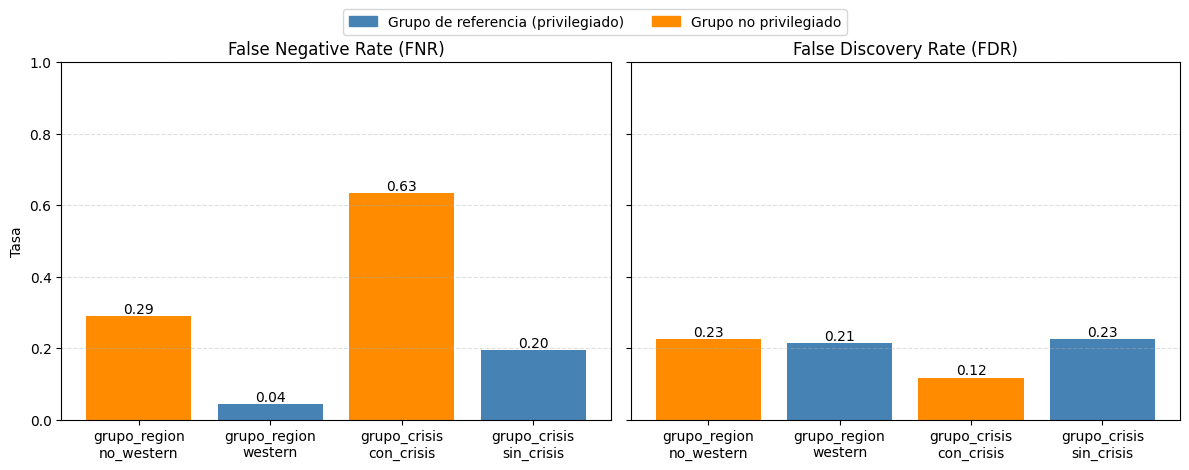

In [30]:
#se lo pedi a claude directamente
# Gráfico de FNR y FDR por grupo
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for eje, metrica, titulo in zip(ejes, ["fnr", "fdr"],
                                ["False Negative Rate (FNR)", "False Discovery Rate (FDR)"]):
    datos = fdf[["attribute_name", "attribute_value", metrica]].copy()
    colores = ["steelblue" if v in grupos_referencia.values() else "darkorange"
               for v in datos["attribute_value"]]
    barras = eje.bar(datos["attribute_name"] + "\n" + datos["attribute_value"],
                     datos[metrica], color=colores)
    eje.bar_label(barras, fmt="%.2f")
    eje.set_title(titulo)
    eje.set_ylim(0, 1)
    eje.grid(axis="y", linestyle="--", alpha=0.4)

ejes[0].set_ylabel("Tasa")
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="steelblue"),
                    plt.Rectangle((0, 0), 1, 1, color="darkorange")],
           labels=["Grupo de referencia (privilegiado)", "Grupo no privilegiado"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()

In [31]:
#promedio "no_western" esconde diferencias entre regiones?
datos_region = test[["score", "label_value", "UN Region"]].copy()
xtab_region, _ = g.get_crosstabs(datos_region)
xtab_region[["attribute_value", "group_size", "prev", "fnr", "fdr"]].rename(
    columns={"prev": "tasa_real_respeto_pleno"}).round(3)

,attribute_value,group_size,tasa_real_respeto_pleno,fnr,fdr
0,Africa,306,0.565,0.578,0.232
1,Asia,264,0.159,0.381,0.574
2,Europe,223,0.605,0.052,0.247
3,Latin America and the Caribbean,215,0.763,0.079,0.179
4,North America,14,1.000,0.000,0.000
5,Oceania,87,0.943,0.012,0.036


In [32]:
#relacion entre otros derechos y la libertad religiosa cambia segun el grupo?
#tomamos los país-años con Freedom of Assembly = 0 (reunion severamente restringida)
#y vemos en que % de ellos igual hay respeto pleno de la libertad religiosa
asamblea = "Freedom of Assembly and Association"
restringida = df_modelo[df_modelo[asamblea] == 0]
plena = df_modelo[df_modelo[asamblea] == 2]

print("% de respeto pleno a la libertad religiosa cuando la libertad de reunión está SEVERAMENTE RESTRINGIDA (0):")
print((restringida.groupby("UN Region")["y"].mean()* 100).round(1).to_string())
print((restringida.groupby("grupo_crisis")["y"].mean()*100).round(1).to_string())

print("\n% de respeto pleno a la libertad religiosa cuando la libertad de reunion es PLENA (2):")
print((plena.groupby("UN Region")["y"].mean() * 100).round(1).to_string())

% de respeto pleno a la libertad religiosa cuando la libertad de reunión está SEVERAMENTE RESTRINGIDA (0):
UN Region
Africa                             38.2
Asia                                7.9
Europe                              4.8
Latin America and the Caribbean    24.7
Oceania                            62.5
grupo_crisis
con_crisis    33.5
sin_crisis    19.3

% de respeto pleno a la libertad religiosa cuando la libertad de reunion es PLENA (2):
UN Region
Africa                             88.2
Asia                               63.1
Europe                             72.6
Latin America and the Caribbean    83.7
North America                      98.4
Oceania                            91.4


### Respuesta 3.1

**Región (western vs. no_western):**
- **FNR:** 0,043 en `western` contra 0,290 en `no_western` → disparidad **6,66**. **No hay paridad.** Con las métricas de la ayudantía: el *recall* de la clase "respeto pleno" es 0,96 en `western` y solo 0,71 en `no_western`. Un país no western que si respeta plenamente la libertad religiosa tiene casi **7 veces** mas probabilidad de ser clasificado como violador.

- **FDR:** 0,214 contra 0,226 -> disparidad 1,05.
<br>
**Hay paridad**: cuando el modelo dice "respeta" se equivoca en proporciones parecidas en ambos grupos.

- El modelo **sobreestima** el respeto en `western` (predice 78,7% cuando el real es 64,7%) y lo **subestima** en `no_western` (predice 47,9% cuando el real es 52,2%).

- **Al desagregar por region, el promedio `no_western` esconde situaciones muy distintas:** en **África** el FNR es **0,578** (mas de la mitad de los pais-años con respeto pleno se clasificaron mal), mientras que en **Asia** el problema es el contrario, con un FDR de **0,574** (mas de la mitad de los casos que el modelo declara "respetuosos" en realidad restringen la libertad religiosa). Latinoamérica tiene errores bajos (FNR 0,079).

**Crisis (sin_crisis vs. con_crisis):**
- **FNR:** 0,195 en `sin_crisis` contra **0,634** en `con_crisis` -> disparidad **3,25**. **No hay paridad.** Casi dos de cada tres país-años de países con historia de crisis que sí respetan la libertad religiosa fueron clasificados como violadores.

- **FDR:** 0,225 contra 0,118 -> disparidad 0,52. **No hay paridad**, pero en la direccion opuesta: el grupo con crisis tiene *menos* falsos descubrimientos. El modelo es mucho más "desconfiado" con estos países: predice respeto pleno en solo el 19,3% de sus casos, cuando el real es 46,6%.

- *Precaución estadística:* el grupo tiene 88 casos y solo 2 falsos positivos, así que su FDR es muy inestable.

**¿Por qué ocurre esto si el modelo no usa la región ni la crisis?** Porque los demás derechos funcionan como **proxies**. En el Taller I (Ítem 5.2) vimos que a nivel global, la libertad religiosa y otros derechos se mueven juntos y el árbol aprende esa regla general: *"si otros derechos están restringidos, la libertad religiosa también"*.
Pero la relacion no es igual en todos los contextos.
<br>
En muchos paises africanos y en los paises que vivieron conflictos, otros derechos (integridad física, reunión, movimiento) están muy restringidos aunque la libertad religiosa se respete y por eso hay tantos falsos negativos.
<br>
En parte de Asia ocurre lo contrario. 
<br>
Además, como eliminamos los años con -77 y -66 (Parte 2), el modelo nunca aprendió de los contextos de crisis, y se equivoca justamente en esos paises

faltaa el 3,2

## Parte 4: Aplique el algoritmo EqOddsPostProcessing sobre las predicciones del modelo de la pregunta 1. Obtenga las predicciones modificadas y evalúelas.

#### Indicaciones:

- Obtenga tanto las instancias de BinaryLabelDatasetMetric como de ClassificationMetric y calcule al menos una métrica de Fairness.

### **RESPONDER**

pregunta 4.1: comentar brevemente los resultados obtenidos, y evaluar los cambios en las métricas de Fairness. Reflexionar sobre los beneficios y limitaciones


In [33]:
### codigo aquí

## **Parte 5** (bonus +5 decimas) :  

Aplique el algoritmo de Reweighing sobre los datos de entrenamiento. Compare las métricas de Fairness para los datos de entrenamiento antes y después de aplicar Reweighing.

Luego, entrene un Arbol de decisión utilizando los datos de entrenamiento modificados y obtenga las métricas de Fairness de las predicciones de dicho modelo.

Analice cómo varió el *accuracy* del modelo respecto al original y las métricas de Fairness y reflexione sobre las implicancias sociales de estas decisiones.

### Indicaciones:
Puedes considerar los grupos priviligiados/no priviligiados mencionados en la parte 3. Considere al menos 2.

In [34]:
### codigo aquí

## Referencias

### Material del curso (ETI195)

Ayudantía ETI195. (2026). *Métricas de evaluación para modelos de clasificación* [Apunte de ayudantía]. Pontificia Universidad Católica de Chile.

Equipo docente ETI195. (2026a). *Taller 1 – Formativo 1* [Diapositivas]. Pontificia Universidad Católica de Chile.

Equipo docente ETI195. (2026b). *Taller 1 – Formativo 2* [Diapositivas]. Pontificia Universidad Católica de Chile.

### Documentación del dataset y herramientas

Cingranelli, D. L., Richards, D. L., & Clay, K. C. (s.f.). *Frequently asked questions*. CIRI Human Rights Data Project. http://www.humanrightsdata.com/p/faq.html

Cingranelli, D. L., Richards, D. L., & Clay, K. C. (2014a). *The CIRI Human Rights Dataset* (Versión 2014.04.14) [Conjunto de datos]. http://www.humanrightsdata.com

Cingranelli, D. L., Richards, D. L., & Clay, K. C. (2014b). *Short variable descriptions for indicators in the Cingranelli-Richards (CIRI) Human Rights Dataset* (Versión 5.21.14). CIRI Human Rights Data Project.

Poe, S. C., Carey, S. C., & Vazquez, T. C. (2001). How are these pictures different? A quantitative comparison of the US State Department and Amnesty International human rights reports, 1976–1995. *Human Rights Quarterly, 23*(3), 650–677. https://muse.jhu.edu/article/13792

Saleiro, P., Kuester, B., Hinkson, L., London, J., Stevens, A., Anisfeld, A., Rodolfa, K. T., & Ghani, R. (2018). *Aequitas: A bias and fairness audit toolkit* (arXiv:1811.05577). arXiv. https://arxiv.org/abs/1811.05577

Ministerio de Asuntos Exteriores, Unión Europea y Cooperación. (s.f.). *Miembros y ampliación*. Representación Permanente de España ante la OTAN. https://www.exteriores.gob.es/RepresentacionesPermanentes/otan/es/Organismo/Paginas/Miembros-y-ampliaci%C3%B3n.aspx

